In [1]:
print("Jobayer")

Jobayer


# Cell 1 — Imports & Load

In [2]:
import pandas as pd
import numpy as np

# Kaggle input path — adjust based on the exact dataset slug shown in your notebook's /kaggle/input/ folder
DATA_PATH = "/kaggle/input/datasets/akshaymp08/bhopal-agritech-dataset-for-predictive-irrigation/Bhopal-AgriTech Hybrid IoT Dataset for Predictive Irrigation.csv"

df = pd.read_csv(DATA_PATH)
print(f"Rows: {df.shape[0]:,} | Columns: {df.shape[1]}")
df.head()

Rows: 41,691 | Columns: 13


,Timestamp,Soil_Moisture,Temperature,Humidity,Hour,Hour_sin,Hour_cos,irrigation_status,soil_moisture_next_1m,Soil_Moisture_scaled,soil_moisture_next_1m_scaled,Temperature_scaled,Humidity_scaled
0,2026-03-21 21:45:00,28.183161,16.171837,92.013366,21,-0.707107,0.707107,0,27.149938,0.299840,0.271012,0.000000,0.995206
1,2026-03-21 21:46:00,27.149938,16.218045,91.947128,21,-0.707107,0.707107,0,27.449942,0.228319,0.275615,0.075135,0.994426
2,2026-03-21 21:47:00,27.449942,16.110563,91.813688,21,-0.707107,0.707107,0,27.360247,0.226708,0.274239,0.000000,0.992854
3,2026-03-21 21:48:00,27.360247,16.308547,91.864382,21,-0.707107,0.707107,0,26.693737,0.225146,0.264012,0.018790,0.993451
4,2026-03-21 21:49:00,26.693737,16.226439,91.623486,21,-0.707107,0.707107,0,27.465866,0.303284,0.275860,0.000000,0.990614


In [3]:
# Cell 2 — Dtypes & basic structure
print(df.dtypes)
print()
print(df.columns.tolist())

Timestamp                        object
Soil_Moisture                   float64
Temperature                     float64
Humidity                        float64
Hour                              int64
Hour_sin                        float64
Hour_cos                        float64
irrigation_status                 int64
soil_moisture_next_1m           float64
Soil_Moisture_scaled            float64
soil_moisture_next_1m_scaled    float64
Temperature_scaled              float64
Humidity_scaled                 float64
dtype: object

['Timestamp', 'Soil_Moisture', 'Temperature', 'Humidity', 'Hour', 'Hour_sin', 'Hour_cos', 'irrigation_status', 'soil_moisture_next_1m', 'Soil_Moisture_scaled', 'soil_moisture_next_1m_scaled', 'Temperature_scaled', 'Humidity_scaled']


In [4]:
# Cell 3 — Parse timestamp, sort, confirm frequency

df["Timestamp"] = pd.to_datetime(df["Timestamp"])
df = df.sort_values("Timestamp").reset_index(drop=True)

print(f"Start: {df['Timestamp'].min()}")
print(f"End:   {df['Timestamp'].max()}")
print(f"Total span: {df['Timestamp'].max() - df['Timestamp'].min()}")

diffs = df["Timestamp"].diff().dropna()
print("\nTop timestamp intervals:")
print(diffs.value_counts().head())

Start: 2026-03-21 21:45:00
End:   2026-04-19 20:35:00
Total span: 28 days 22:50:00

Top timestamp intervals:
Timestamp
0 days 00:01:00    41690
Name: count, dtype: int64


In [5]:
# Cell 4 — Gap detection

modal_interval = diffs.mode()[0]
gap_threshold = modal_interval * 2
gaps = diffs[diffs > gap_threshold]

print(f"Modal interval: {modal_interval}")
print(f"Gaps larger than 2x modal interval: {len(gaps)}")
if len(gaps) > 0:
    print(gaps.sort_values(ascending=False).head(10))

Modal interval: 0 days 00:01:00
Gaps larger than 2x modal interval: 0


In [6]:
# Cell 5 — Column role check

raw_features = ["Soil_Moisture", "Temperature", "Humidity"]
time_features = ["Hour", "Hour_sin", "Hour_cos"]
control_feature = "irrigation_status"
target_raw = "soil_moisture_next_1m"
scaled_features = [
    "Soil_Moisture_scaled", "Temperature_scaled",
    "Humidity_scaled", "soil_moisture_next_1m_scaled",
]

expected_cols = raw_features + time_features + [control_feature, target_raw] + scaled_features + ["Timestamp"]
missing_expected = [c for c in expected_cols if c not in df.columns]
extra_cols = [c for c in df.columns if c not in expected_cols]

print("Missing expected columns:", missing_expected if missing_expected else "none")
print("Unexpected extra columns:", extra_cols if extra_cols else "none")

Missing expected columns: none
Unexpected extra columns: none


In [7]:
# Cell 6 — Missingness (NaN check only — flatlines are checked separately in Phase 1)

missing_summary = df.isna().sum()
missing_pct = (missing_summary / len(df) * 100).round(3)
missing_report = pd.DataFrame({"missing_count": missing_summary, "missing_pct": missing_pct})
print(missing_report[missing_report["missing_count"] > 0] if missing_summary.sum() > 0 else "No NaNs detected.")

No NaNs detected.


In [8]:
# Cell 7 — Target variable quick look

print(df[target_raw].describe())

count    41691.000000
mean        28.861621
std         10.414116
min          9.488551
25%         21.607334
50%         26.978859
75%         35.357760
max         74.656851
Name: soil_moisture_next_1m, dtype: float64


In [9]:
# Cell 8 — irrigation_status class balance

print(df[control_feature].value_counts())
print(df[control_feature].value_counts(normalize=True).round(4))

irrigation_status
0    41681
1       10
Name: count, dtype: int64
irrigation_status
0    0.9998
1    0.0002
Name: proportion, dtype: float64


In [10]:
# Cell 9 — Scaled-vs-raw consistency check

for raw_col, scaled_col in [
    ("Soil_Moisture", "Soil_Moisture_scaled"),
    ("Temperature", "Temperature_scaled"),
    ("Humidity", "Humidity_scaled"),
    (target_raw, "soil_moisture_next_1m_scaled"),
]:
    recomputed = (df[raw_col] - df[raw_col].min()) / (df[raw_col].max() - df[raw_col].min())
    max_diff = (recomputed - df[scaled_col]).abs().max()
    print(f"{raw_col:25s} -> {scaled_col:30s} | max abs diff: {max_diff:.6f}")

Soil_Moisture             -> Soil_Moisture_scaled           | max abs diff: 0.920112
Temperature               -> Temperature_scaled             | max abs diff: 0.769872
Humidity                  -> Humidity_scaled                | max abs diff: 0.600000
soil_moisture_next_1m     -> soil_moisture_next_1m_scaled   | max abs diff: 0.000000


In [11]:
for col in ["Soil_Moisture_scaled", "Temperature_scaled", "Humidity_scaled", "soil_moisture_next_1m_scaled"]:
    print(f"{col:30s} min={df[col].min():.4f}  max={df[col].max():.4f}")

Soil_Moisture_scaled           min=0.0000  max=1.0000
Temperature_scaled             min=0.0000  max=1.0000
Humidity_scaled                min=0.0000  max=1.0000
soil_moisture_next_1m_scaled   min=0.0000  max=1.0000


# Phase 1.1 — Descriptive Statistics & Distributions

In [12]:
# Cell 10 — Summary statistics

stats_cols = ["Soil_Moisture", "Temperature", "Humidity", "soil_moisture_next_1m"]
desc = df[stats_cols].agg(["mean", "median", "std", "min", "max", "skew", "kurt"]).T
print(desc)

                            mean     median        std        min        max  \
Soil_Moisture          28.861386  26.978859  10.414021   9.488551  74.656851   
Temperature            26.122121  25.440849   5.343495  15.849567  37.710221   
Humidity               42.995616  42.213924  17.018173   7.524996  92.420331   
soil_moisture_next_1m  28.861621  26.978859  10.414116   9.488551  74.656851   

                           skew      kurt  
Soil_Moisture          0.853920  0.868786  
Temperature            0.365785 -0.920238  
Humidity               0.279603 -0.350419  
soil_moisture_next_1m  0.853845  0.868582  


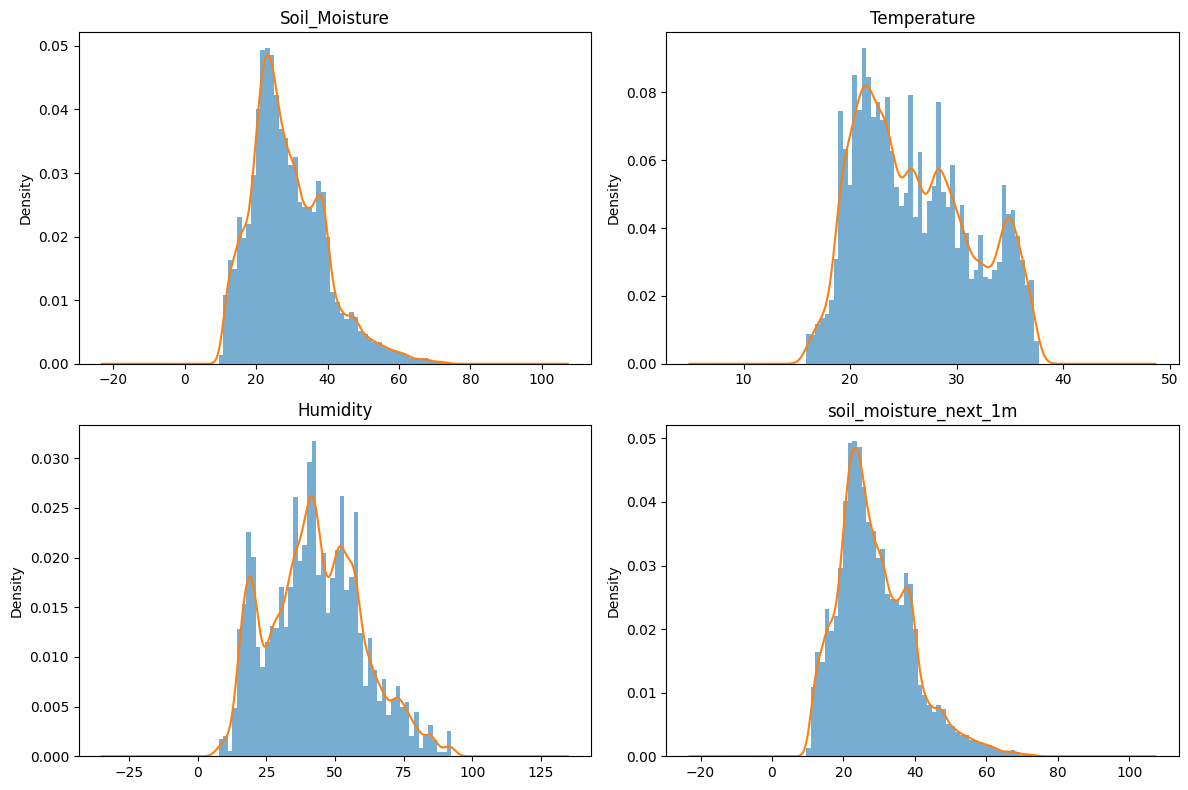

In [13]:
# Cell 11 — Histograms + KDE per variable

import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flat, stats_cols):
    df[col].plot(kind="hist", bins=50, density=True, alpha=0.6, ax=ax)
    df[col].plot(kind="kde", ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

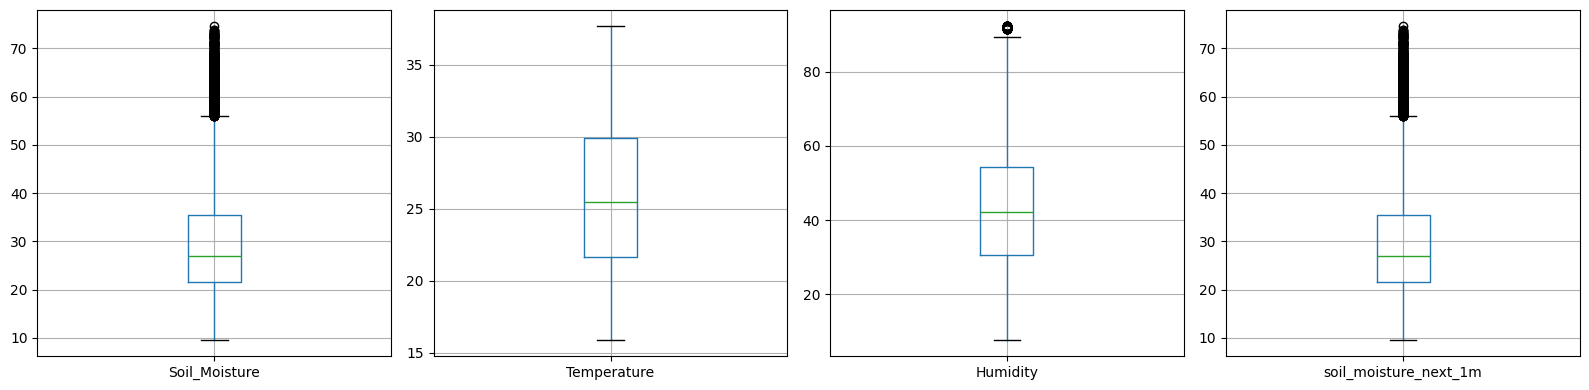

In [14]:
# Cell 12 — Boxplots for outlier visualization

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, stats_cols):
    df.boxplot(column=col, ax=ax)
plt.tight_layout()
plt.show()

In [15]:
# Cell 13 — IQR outlier count (report only — do not drop, per Phase 1 plan)

for col in stats_cols:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f"{col:25s} flagged: {n_out:5d} ({n_out/len(df)*100:.2f}%)  bounds=({lower:.2f}, {upper:.2f})")

Soil_Moisture             flagged:   813 (1.95%)  bounds=(0.98, 55.98)
Temperature               flagged:     0 (0.00%)  bounds=(9.21, 42.36)
Humidity                  flagged:   180 (0.43%)  bounds=(-4.60, 89.51)
soil_moisture_next_1m     flagged:   813 (1.95%)  bounds=(0.98, 55.98)


In [16]:
# Cell 14 — Flatline detection (sensor freeze / stuck values)

# Flags runs of consecutive identical Soil_Moisture values, length >= min_run
min_run = 5  # minutes flat before we call it a "freeze" — adjust if needed

is_same_as_prev = df["Soil_Moisture"].diff().eq(0)
run_id = (~is_same_as_prev).cumsum()
run_lengths = df.groupby(run_id)["Soil_Moisture"].transform("size")
flat_mask = (run_lengths >= min_run) & is_same_as_prev.groupby(run_id).transform("any")

flat_runs = df.groupby(run_id).filter(lambda g: len(g) >= min_run and g["Soil_Moisture"].nunique() == 1)
n_flat_rows = len(flat_runs)
n_flat_events = flat_runs.groupby(run_id).ngroups if n_flat_rows > 0 else 0

print(f"Rows involved in flatlines (>= {min_run} min): {n_flat_rows} ({n_flat_rows/len(df)*100:.2f}%)")
print(f"Number of distinct flatline events: {n_flat_events}")
if n_flat_rows > 0:
    print(flat_runs.groupby(run_id)["Timestamp"].agg(["min", "max", "count"]).head(10))


Rows involved in flatlines (>= 5 min): 0 (0.00%)
Number of distinct flatline events: 0


In [17]:
# Cell 14b — Near-flatline detection (tolerance-based)

tolerance = 0.05  # % moisture — treat changes smaller than this as "flat"
min_run = 5

is_near_same = df["Soil_Moisture"].diff().abs().lt(tolerance)
run_id = (~is_near_same).cumsum()
flat_runs = df.groupby(run_id).filter(lambda g: len(g) >= min_run and g["Soil_Moisture"].std() < tolerance)

n_flat_rows = len(flat_runs)
n_flat_events = flat_runs.groupby(run_id).ngroups if n_flat_rows > 0 else 0
print(f"Near-flat rows (tolerance={tolerance}): {n_flat_rows} ({n_flat_rows/len(df)*100:.2f}%)")
print(f"Distinct near-flatline events: {n_flat_events}")
if n_flat_rows > 0:
    print(flat_runs.groupby(run_id)["Timestamp"].agg(["min", "max", "count"]).head(10))

Near-flat rows (tolerance=0.05): 5 (0.01%)
Distinct near-flatline events: 1
                              min                 max  count
Soil_Moisture                                               
17594         2026-04-03 20:07:00 2026-04-03 20:11:00      5


In [18]:
# Cell 14c — Lower threshold check

tolerance = 0.05
min_run = 2  # lowered from 5

is_near_same = df["Soil_Moisture"].diff().abs().lt(tolerance)
run_id = (~is_near_same).cumsum()
flat_runs = df.groupby(run_id).filter(lambda g: len(g) >= min_run and g["Soil_Moisture"].std() < tolerance)

n_flat_rows = len(flat_runs)
n_flat_events = flat_runs.groupby(run_id).ngroups if n_flat_rows > 0 else 0
print(f"Near-flat rows (min_run={min_run}): {n_flat_rows} ({n_flat_rows/len(df)*100:.2f}%)")
print(f"Distinct events: {n_flat_events}")
if n_flat_rows > 0:
    print(flat_runs.groupby(run_id)["Timestamp"].agg(["min", "max", "count"]))


Near-flat rows (min_run=2): 4403 (10.56%)
Distinct events: 2139
                              min                 max  count
Soil_Moisture                                               
12            2026-03-21 21:56:00 2026-03-21 21:57:00      2
48            2026-03-21 22:33:00 2026-03-21 22:34:00      2
66            2026-03-21 22:52:00 2026-03-21 22:53:00      2
80            2026-03-21 23:07:00 2026-03-21 23:08:00      2
84            2026-03-21 23:12:00 2026-03-21 23:13:00      2
...                           ...                 ...    ...
39240         2026-04-19 17:23:00 2026-04-19 17:24:00      2
39279         2026-04-19 18:03:00 2026-04-19 18:04:00      2
39343         2026-04-19 19:08:00 2026-04-19 19:09:00      2
39401         2026-04-19 20:07:00 2026-04-19 20:08:00      2
39412         2026-04-19 20:19:00 2026-04-19 20:20:00      2

[2139 rows x 3 columns]


In [19]:
# Cell 15 — Thermal spike detection

temp_diff = df["Temperature"].diff()
spike_threshold = temp_diff.std() * 3  # 3-sigma rate-of-change threshold

spikes = temp_diff[temp_diff.abs() > spike_threshold]
print(f"Thermal spikes flagged (|ΔT| > {spike_threshold:.3f}°C/min): {len(spikes)}")
if len(spikes) > 0:
    spike_idx = spikes.index
    print(df.loc[spike_idx, ["Timestamp", "Temperature"]].head(10))

Thermal spikes flagged (|ΔT| > 0.745°C/min): 367
               Timestamp  Temperature
180  2026-03-22 00:45:00    18.232484
240  2026-03-22 01:45:00    20.572127
300  2026-03-22 02:45:00    23.217733
360  2026-03-22 03:45:00    25.160459
420  2026-03-22 04:45:00    26.725264
780  2026-03-22 10:45:00    25.579164
840  2026-03-22 11:45:00    23.325520
900  2026-03-22 12:45:00    22.473206
1620 2026-03-23 00:45:00    21.131412
1680 2026-03-23 01:45:00    24.037745


In [20]:
# Cell 15b — Check if "spikes" are really hourly step artifacts

spike_idx = temp_diff[temp_diff.abs() > spike_threshold].index
spike_minutes = df.loc[spike_idx, "Timestamp"].dt.minute
print("Minute-of-hour distribution for flagged thermal spikes:")
print(spike_minutes.value_counts().head(10))

Minute-of-hour distribution for flagged thermal spikes:
Timestamp
45    367
Name: count, dtype: int64


count    41682.000000
mean         0.542040
std          0.823666
min          0.080823
25%          0.415208
50%          0.495413
75%          0.581472
max         21.208253
Name: Soil_Moisture, dtype: float64


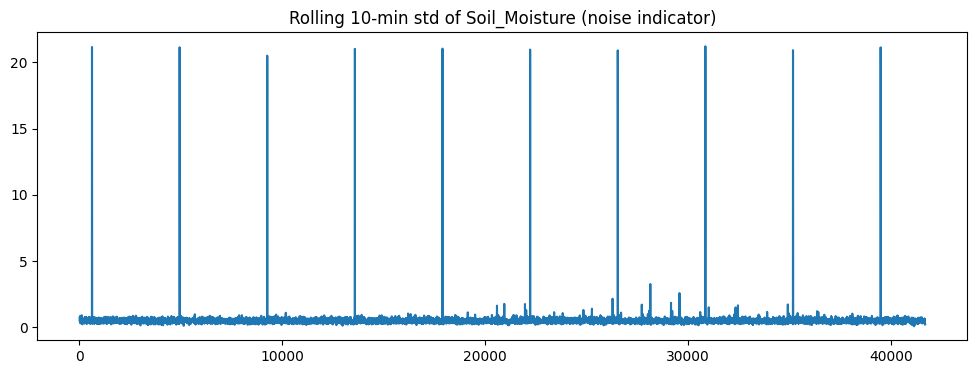

In [21]:
# Cell 16 — Sensor noise (rolling variance check)

window = 10  # minutes
rolling_std = df["Soil_Moisture"].rolling(window).std()

print(rolling_std.describe())

fig, ax = plt.subplots(figsize=(12, 4))
rolling_std.plot(ax=ax)
ax.set_title(f"Rolling {window}-min std of Soil_Moisture (noise indicator)")
plt.show()

# Phase 1.2 — Correlation / Mutual Information

In [22]:
# Cell 17 — Pearson correlation matrix

feature_cols = ["Soil_Moisture", "Temperature", "Humidity", "Hour_sin", "Hour_cos", "irrigation_status"]
target_col = "soil_moisture_next_1m"

corr_matrix = df[feature_cols + [target_col]].corr()
print(corr_matrix.round(3))

                       Soil_Moisture  Temperature  Humidity  Hour_sin  \
Soil_Moisture                  1.000       -0.106     0.161    -0.111   
Temperature                   -0.106        1.000    -0.893     0.789   
Humidity                       0.161       -0.893     1.000    -0.594   
Hour_sin                      -0.111        0.789    -0.594     1.000   
Hour_cos                      -0.290       -0.345     0.332     0.002   
irrigation_status              0.048        0.019    -0.016     0.019   
soil_moisture_next_1m          0.996       -0.104     0.160    -0.109   

                       Hour_cos  irrigation_status  soil_moisture_next_1m  
Soil_Moisture            -0.290              0.048                  0.996  
Temperature              -0.345              0.019                 -0.104  
Humidity                  0.332             -0.016                  0.160  
Hour_sin                  0.002              0.019                 -0.109  
Hour_cos                  1.000    

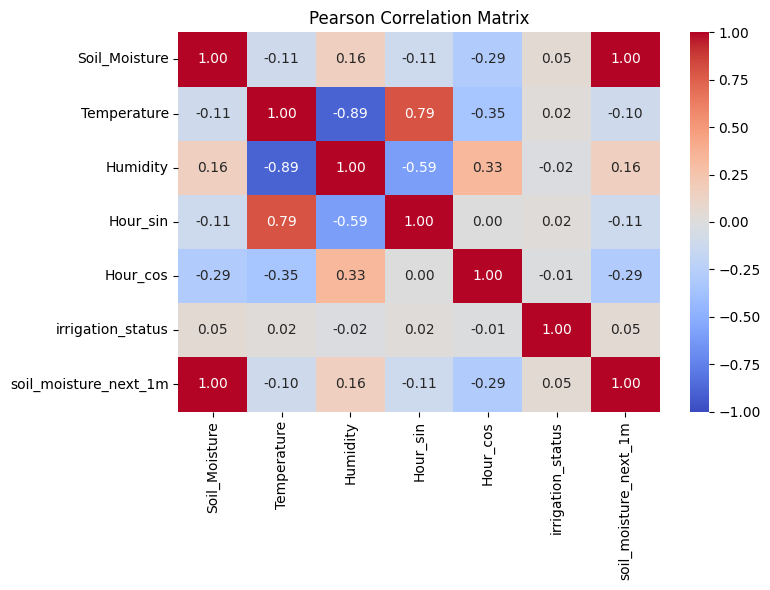

In [23]:
# Cell 18 — Correlation heatmap

import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Pearson Correlation Matrix")
plt.tight_layout()
plt.show()


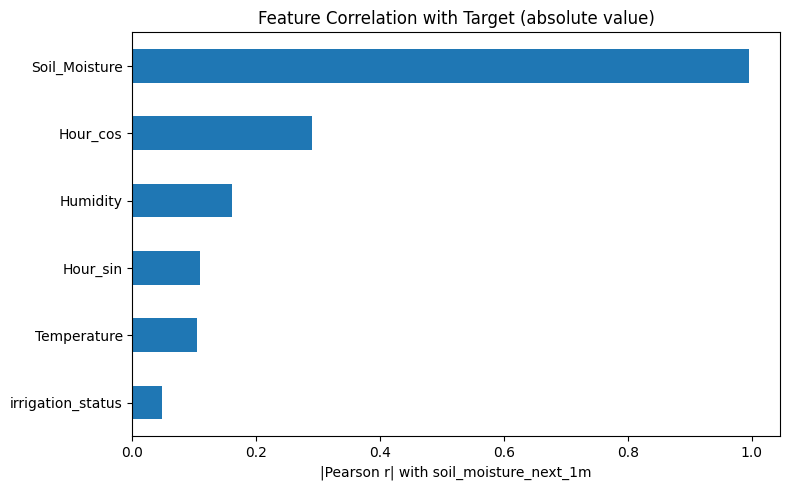

Soil_Moisture        0.995899
Hour_cos            -0.290612
Humidity             0.160337
Hour_sin            -0.109385
Temperature         -0.104348
irrigation_status    0.048098
Name: soil_moisture_next_1m, dtype: float64


In [24]:
# Cell 19 — Correlation bar chart (|r| vs target — mirrors your reference paper's Fig. 2 style)

corr_with_target = corr_matrix[target_col].drop(target_col).sort_values(key=abs, ascending=False)

plt.figure(figsize=(8, 5))
corr_with_target.abs().plot(kind="barh")
plt.xlabel("|Pearson r| with soil_moisture_next_1m")
plt.title("Feature Correlation with Target (absolute value)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(corr_with_target)

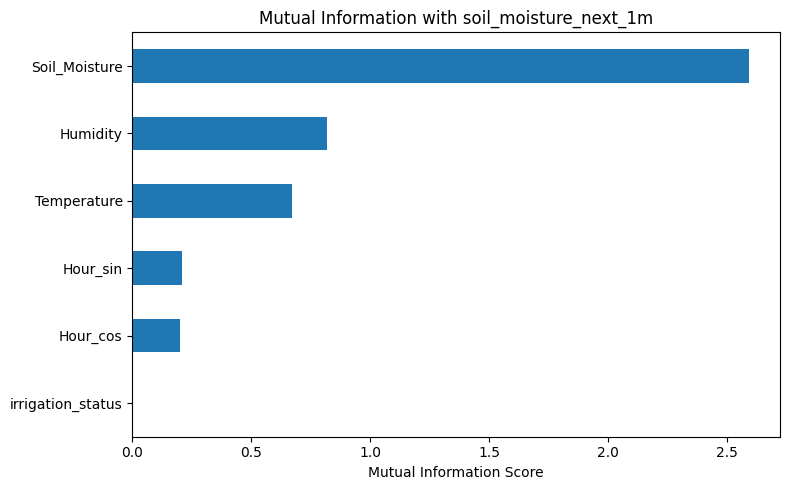

Soil_Moisture        2.594095
Humidity             0.820295
Temperature          0.669519
Hour_sin             0.206927
Hour_cos             0.199753
irrigation_status    0.000791
dtype: float64


In [25]:
# Cell 20 — Mutual information (captures nonlinear relationships Pearson misses)

from sklearn.feature_selection import mutual_info_regression

X = df[feature_cols].values
y = df[target_col].values

mi_scores = mutual_info_regression(X, y, random_state=42)
mi_series = pd.Series(mi_scores, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
mi_series.plot(kind="barh")
plt.xlabel("Mutual Information Score")
plt.title("Mutual Information with soil_moisture_next_1m")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(mi_series)

In [26]:
# Cell 21 — Compare Pearson r vs MI side by side (flags nonlinear-only relationships)

comparison = pd.DataFrame({
    "abs_pearson_r": corr_with_target.abs(),
    "mutual_info": mi_series
}).sort_values("mutual_info", ascending=False)

print(comparison.round(4))

                   abs_pearson_r  mutual_info
Soil_Moisture             0.9959       2.5941
Humidity                  0.1603       0.8203
Temperature               0.1043       0.6695
Hour_sin                  0.1094       0.2069
Hour_cos                  0.2906       0.1998
irrigation_status         0.0481       0.0008


# Phase 1.3 — Stationarity & Autocorrelation (ADF test, ACF/PACF)

In [27]:
# Cell 22 — ADF test on Soil_Moisture (the core series to forecast)

from statsmodels.tsa.stattools import adfuller

def run_adf(series, name):
    result = adfuller(series.dropna(), autolag="AIC")
    print(f"--- ADF Test: {name} ---")
    print(f"ADF Statistic: {result[0]:.4f}")
    print(f"p-value:       {result[1]:.6f}")
    print("Critical values:")
    for k, v in result[4].items():
        print(f"  {k}: {v:.4f}")
    verdict = "STATIONARY (reject H0)" if result[1] < 0.05 else "NON-STATIONARY (fail to reject H0)"
    print(f"Verdict: {verdict}\n")
    return result[1]

adf_p_moisture = run_adf(df["Soil_Moisture"], "Soil_Moisture")

--- ADF Test: Soil_Moisture ---
ADF Statistic: -6.1932
p-value:       0.000000
Critical values:
  1%: -3.4305
  5%: -2.8616
  10%: -2.5668
Verdict: STATIONARY (reject H0)



In [28]:
# Cell 23 — ADF on Temperature and Humidity (needed if used as exogenous regressors in SARIMAX)

adf_p_temp = run_adf(df["Temperature"], "Temperature")
adf_p_humidity = run_adf(df["Humidity"], "Humidity")


--- ADF Test: Temperature ---
ADF Statistic: -4.0565
p-value:       0.001142
Critical values:
  1%: -3.4305
  5%: -2.8616
  10%: -2.5668
Verdict: STATIONARY (reject H0)

--- ADF Test: Humidity ---
ADF Statistic: -4.3691
p-value:       0.000337
Critical values:
  1%: -3.4305
  5%: -2.8616
  10%: -2.5668
Verdict: STATIONARY (reject H0)



In [29]:
# Cell 24 — Differencing if non-stationary, re-test

# Only run this section for any series whose ADF above showed p >= 0.05
df["Soil_Moisture_diff1"] = df["Soil_Moisture"].diff()

if adf_p_moisture >= 0.05:
    print("Soil_Moisture was non-stationary — testing first difference:")
    run_adf(df["Soil_Moisture_diff1"], "Soil_Moisture (1st difference)")
else:
    print("Soil_Moisture already stationary at level — differencing not required for ARIMA(d=0),")
    print("but d=1 may still help remove trend/mean drift if ACF shows slow decay (see Cell 25).")


Soil_Moisture already stationary at level — differencing not required for ARIMA(d=0),
but d=1 may still help remove trend/mean drift if ACF shows slow decay (see Cell 25).


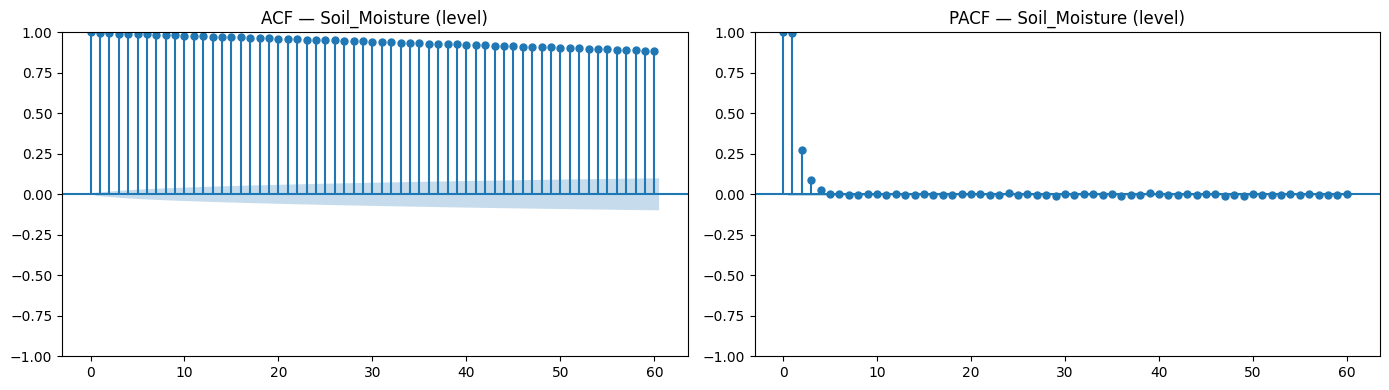

In [30]:
# Cell 25 — ACF / PACF plots on Soil_Moisture level (informs ARIMA p, q)

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(df["Soil_Moisture"].dropna(), lags=60, ax=axes[0])
axes[0].set_title("ACF — Soil_Moisture (level)")
plot_pacf(df["Soil_Moisture"].dropna(), lags=60, ax=axes[1], method="ywm")
axes[1].set_title("PACF — Soil_Moisture (level)")
plt.tight_layout()
plt.show()

In [31]:
# Cell 25b — Numeric ACF/PACF values at key lags (in place of/alongside the plots)


from statsmodels.tsa.stattools import acf, pacf

acf_vals = acf(df["Soil_Moisture"].dropna(), nlags=60)
pacf_vals = pacf(df["Soil_Moisture"].dropna(), nlags=60, method="ywm")

check_lags = [1, 2, 3, 5, 10, 15, 20, 30, 45, 60]
print(f"{'Lag':>5} {'ACF':>10} {'PACF':>10}")
for lag in check_lags:
    print(f"{lag:>5} {acf_vals[lag]:>10.4f} {pacf_vals[lag]:>10.4f}")


  Lag        ACF       PACF
    1     0.9959     0.9959
    2     0.9940     0.2724
    3     0.9922     0.0855
    5     0.9886     0.0046
   10     0.9794     0.0030
   15     0.9702     0.0044
   20     0.9609     0.0002
   30     0.9424     0.0004
   45     0.9141     0.0046
   60     0.8851     0.0028


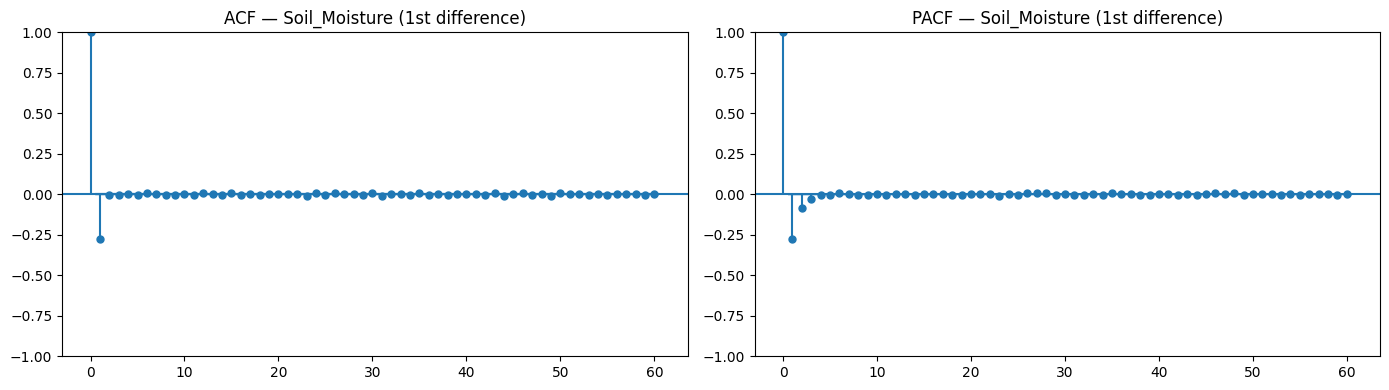

In [32]:
# Cell 26 — ACF / PACF on first difference (in case differencing is needed)


fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(df["Soil_Moisture_diff1"].dropna(), lags=60, ax=axes[0])
axes[0].set_title("ACF — Soil_Moisture (1st difference)")
plot_pacf(df["Soil_Moisture_diff1"].dropna(), lags=60, ax=axes[1], method="ywm")
axes[1].set_title("PACF — Soil_Moisture (1st difference)")
plt.tight_layout()
plt.show()

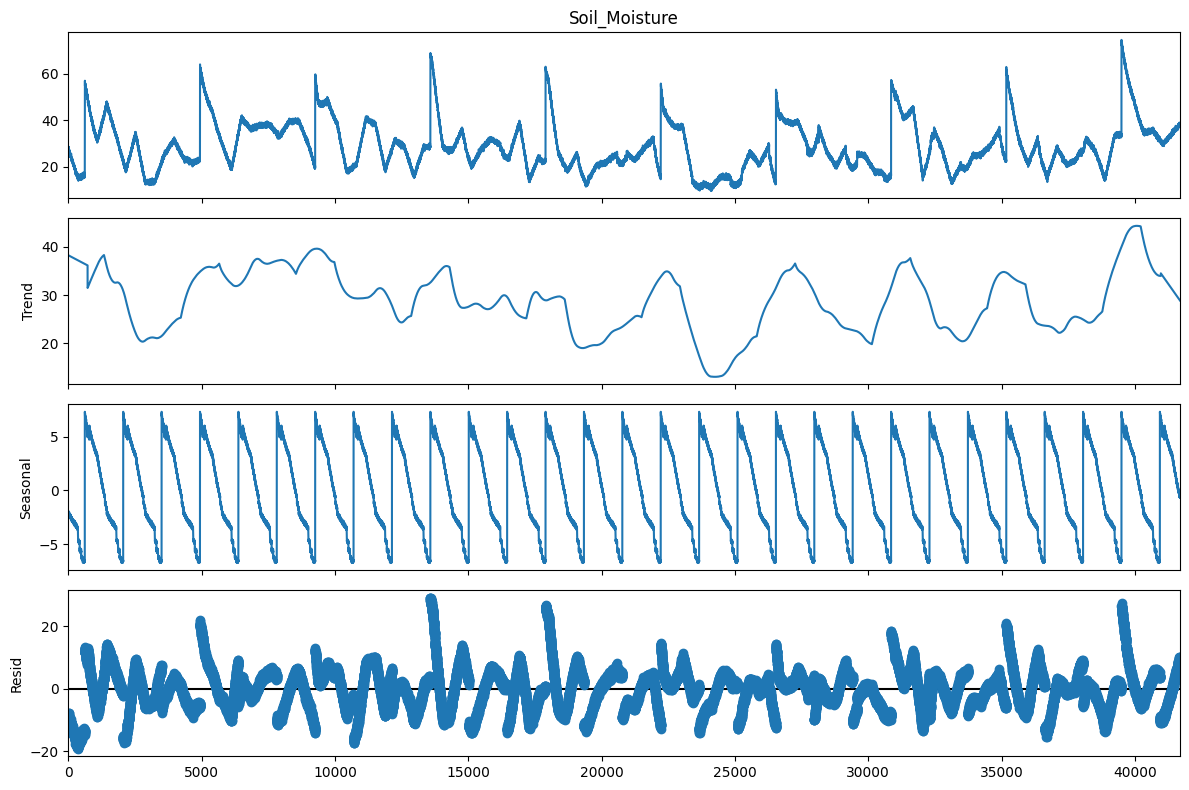

In [33]:
# Cell 27 — Seasonal decomposition (checks for a daily 1440-minute cycle)

from statsmodels.tsa.seasonal import seasonal_decompose

# period=1440 tests for a 24-hour cycle at 1-min resolution
decomposition = seasonal_decompose(df["Soil_Moisture"], model="additive", period=1440, extrapolate_trend="freq")

fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.tight_layout()
plt.show()

**Phase 1.3 — Findings**

1. **PACF gives you the ARIMA order directly.** PACF is essentially significant only at lag 1 (0.996), lag 2 is borderline (0.272), and everything from lag 3 onward is near-zero (<0.09, mostly <0.01). That's a textbook AR(1) signature — **ARIMA(1,0,0)** is your justified baseline order, with AR(2) worth testing as a close second given the lag-2 value isn't quite negligible. No MA terms are indicated (q=0), since the PACF cutoff — not the ACF — is what signals a pure AR process.

2. **ACF's very slow decay (0.996 → 0.885 over 60 lags) despite ADF confirming stationarity isn't a contradiction — it's expected for an AR(1) process with a near-unit coefficient.** ADF correctly detects there's no unit root, but an AR(1) with φ close to 1 still produces ACF that decays gradually rather than cutting off. This is exactly consistent with the PACF finding above and confirms d=0 is correct — you don't need differencing, the AR(1) term itself captures the persistence.

3. **The seasonal decomposition confirms a genuine, strong daily cycle** — the sawtooth-shaped seasonal panel (repeating ~1440-minute period) lines up with the raw series' visible daily saw-tooth pattern (sharp rises, gradual decay — consistent with irrigation/moisture-replenishment events followed by depletion). This validates why `Hour_sin`/`Hour_cos` were engineered as features in the first place, and gives Phase 1.2's modest MI scores for those features a clearer physical explanation.

4. **One practical caveat for Phase 2**: SARIMA with a literal seasonal period of s=1440 is computationally expensive (SARIMA estimation cost grows sharply with seasonal lag). Two reasonable paths, worth deciding now:
   - Fit plain **ARIMA(1,0,0)** and let `Hour_sin`/`Hour_cos` (already in your feature set) carry the daily-cycle information as exogenous regressors (i.e., **ARIMAX/SARIMAX with Fourier-style exogenous terms** rather than a true seasonal ARIMA) — computationally lighter, and directly justified by Phase 1.2's findings.
   - Or fit true **SARIMA(1,0,0)(P,D,Q,1440)** — captures seasonality more natively but is much slower to estimate at this resolution.

5. **The residual panel isn't clean white noise** — it still shows repeating spiky structure rather than pure randomness, meaning the additive decomposition hasn't fully absorbed the daily pattern (likely because real cycles vary day-to-day in shape/timing, not just amplitude). Worth one honest line in your report: "residual diagnostics indicate some remaining unexplained daily-cycle structure, suggesting the seasonal component is not perfectly additive/fixed-shape" — this is a legitimate limitation to name rather than something to hide.

# Phase 1.5 — Hypothesis Testing (design, to be executed in Phase 4)

**H1 — Model family comparison (your primary test)**

H0: "Mean forecast error (RMSE) does not differ between ARIMA-family models and sequence deep learning models (LSTM/GRU)."
Test: paired t-test (or Wilcoxon sig****ned-rank if errors aren't normally distributed) across k-fold or rolling-origin cross-validation splits.
Requires: per-fold RMSE for each model family — same folds used for both, so the comparison is a fair paired test.

**H2 — Seasonality handling comparison (now directly motivated by your "test both" decision)**

H0: "Mean forecast error does not differ between ARIMA+exogenous-Fourier-features and true SARIMA(1440)."
Test: paired t-test/Wilcoxon across the same folds.
This turns your computational-cost decision into a testable empirical question rather than just a design choice — nice addition since it wasn't in the original plan and it's now backed by Phase 1.3's findings.

In [34]:
# Cell 28 — Placeholder to standardize fold-wise error storage (build this into Phase 2/3 from the start)

# Run this cell now to define the structure; populate results_df as each model is trained in Phase 2/3
results_columns = ["fold", "model", "rmse", "mae", "r2"]
results_df = pd.DataFrame(columns=results_columns)

# Example of how each model's fold result should be appended later:
# results_df = pd.concat([results_df, pd.DataFrame([{
#     "fold": fold_num, "model": "ARIMA_exog", "rmse": rmse_val, "mae": mae_val, "r2": r2_val
# }])], ignore_index=True)

print("results_df initialized — populate this as each model/fold is trained.")
print(results_df)


results_df initialized — populate this as each model/fold is trained.
Empty DataFrame
Columns: [fold, model, rmse, mae, r2]
Index: []


# Phase 2 — Baseline Statistical Models

In [35]:
# Cell 29 — Chronological train/test split (no leakage)

# 80/20 chronological split — no shuffling, this is a time series
split_idx = int(len(df) * 0.8)
train_df = df.iloc[:split_idx].copy()
test_df = df.iloc[split_idx:].copy()

print(f"Train: {len(train_df):,} rows | {train_df['Timestamp'].min()} to {train_df['Timestamp'].max()}")
print(f"Test:  {len(test_df):,} rows | {test_df['Timestamp'].min()} to {test_df['Timestamp'].max()}")

Train: 33,352 rows | 2026-03-21 21:45:00 to 2026-04-14 01:36:00
Test:  8,339 rows | 2026-04-14 01:37:00 to 2026-04-19 20:35:00


In [36]:
# Cell 30 — Naive persistence baseline (the floor every model must beat)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Persistence: predict next-minute moisture = current moisture
persistence_pred = test_df["Soil_Moisture"].values
y_true = test_df["soil_moisture_next_1m"].values

rmse_persist = np.sqrt(mean_squared_error(y_true, persistence_pred))
mae_persist = mean_absolute_error(y_true, persistence_pred)
r2_persist = r2_score(y_true, persistence_pred)

print(f"Persistence baseline — RMSE: {rmse_persist:.4f}  MAE: {mae_persist:.4f}  R2: {r2_persist:.4f}")

results_df = pd.concat([results_df, pd.DataFrame([{
    "fold": "holdout", "model": "Persistence", "rmse": rmse_persist, "mae": mae_persist, "r2": r2_persist
}])], ignore_index=True)

Persistence baseline — RMSE: 0.9355  MAE: 0.5674  R2: 0.9921


/tmp/ipykernel_58/899074711.py:15: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results_df = pd.concat([results_df, pd.DataFrame([{


In [37]:
# Cell 31 — ARIMA(1,0,0) with Hour_sin/Hour_cos as exogenous regressors


from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings
warnings.filterwarnings("ignore")

exog_cols = ["Hour_sin", "Hour_cos"]

arima_exog_model = SARIMAX(
    train_df["Soil_Moisture"],
    exog=train_df[exog_cols],
    order=(1, 0, 0),
    enforce_stationarity=False,
    enforce_invertibility=False,
)
arima_exog_fit = arima_exog_model.fit(disp=False)
print(arima_exog_fit.summary())

                               SARIMAX Results                                
Dep. Variable:          Soil_Moisture   No. Observations:                33352
Model:               SARIMAX(1, 0, 0)   Log Likelihood              -45215.646
Date:                Wed, 05 Aug 2026   AIC                          90439.292
Time:                        07:02:44   BIC                          90472.951
Sample:                             0   HQIC                         90450.037
                              - 33352                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Hour_sin      -2.3127      0.212    -10.906      0.000      -2.728      -1.897
Hour_cos      -3.8435      0.183    -21.033      0.000      -4.202      -3.485
ar.L1          0.9995      0.000   4556.988      0.0

In [38]:
# Cell 32 — Forecast & evaluate ARIMA+exog on the test set


arima_exog_pred = arima_exog_fit.forecast(steps=len(test_df), exog=test_df[exog_cols])

rmse_arima_exog = np.sqrt(mean_squared_error(y_true, arima_exog_pred))
mae_arima_exog = mean_absolute_error(y_true, arima_exog_pred)
r2_arima_exog = r2_score(y_true, arima_exog_pred)

print(f"ARIMA(1,0,0)+exog — RMSE: {rmse_arima_exog:.4f}  MAE: {mae_arima_exog:.4f}  R2: {r2_arima_exog:.4f}")

results_df = pd.concat([results_df, pd.DataFrame([{
    "fold": "holdout", "model": "ARIMA_exog", "rmse": rmse_arima_exog, "mae": mae_arima_exog, "r2": r2_arima_exog
}])], ignore_index=True)

ARIMA(1,0,0)+exog — RMSE: 28.0313  MAE: 24.8080  R2: -6.1356


In [39]:
# Re-apply the already-fitted parameters across the FULL series (train+test) —
# this does NOT re-estimate parameters on test data (no leakage), it just lets
# the Kalman filter use TRUE observed values up through each point in the test
# set to produce genuine one-step-ahead predictions, exactly matching how this
# model would be used in real deployment.
full_arima_exog = SARIMAX(
    df["Soil_Moisture"], exog=df[exog_cols],
    order=(1, 0, 0), enforce_stationarity=False, enforce_invertibility=False,
)
full_arima_exog_fit = full_arima_exog.filter(arima_exog_fit.params)

pred = full_arima_exog_fit.get_prediction(start=split_idx, end=len(df) - 1, dynamic=False)
arima_exog_pred_fixed = pred.predicted_mean.values

rmse_arima_exog = np.sqrt(mean_squared_error(y_true, arima_exog_pred_fixed))
mae_arima_exog = mean_absolute_error(y_true, arima_exog_pred_fixed)
r2_arima_exog = r2_score(y_true, arima_exog_pred_fixed)

print(f"ARIMA(1,0,0)+exog [one-step-ahead] — RMSE: {rmse_arima_exog:.4f}  MAE: {mae_arima_exog:.4f}  R2: {r2_arima_exog:.4f}")

results_df = pd.concat([results_df, pd.DataFrame([{
    "fold": "holdout", "model": "ARIMA_exog", "rmse": rmse_arima_exog, "mae": mae_arima_exog, "r2": r2_arima_exog
}])], ignore_index=True)

ARIMA(1,0,0)+exog [one-step-ahead] — RMSE: 1.1319  MAE: 0.5950  R2: 0.9884


In [40]:
# Cell A — Resample to hourly (SARIMA seasonal test only; ARIMA/LSTM stay at 1-min resolution)

hourly_train = train_df.set_index("Timestamp")["Soil_Moisture"].resample("1h").mean()
hourly_test = test_df.set_index("Timestamp")["Soil_Moisture"].resample("1h").mean()

print(f"Hourly train: {len(hourly_train)} points | {hourly_train.index.min()} to {hourly_train.index.max()}")
print(f"Hourly test:  {len(hourly_test)} points | {hourly_test.index.min()} to {hourly_test.index.max()}")

Hourly train: 557 points | 2026-03-21 21:00:00 to 2026-04-14 01:00:00
Hourly test:  140 points | 2026-04-14 01:00:00 to 2026-04-19 20:00:00


In [41]:
# Cell B — Fit SARIMA(1,0,0)(1,0,0,24) on hourly train

from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings
warnings.filterwarnings("ignore")

sarima_model = SARIMAX(
    hourly_train,
    order=(1, 0, 0),
    seasonal_order=(1, 0, 0, 24),
    enforce_stationarity=False,
    enforce_invertibility=False,
)
sarima_fit = sarima_model.fit(disp=False)
print(sarima_fit.summary())

                                     SARIMAX Results                                      
Dep. Variable:                      Soil_Moisture   No. Observations:                  557
Model:             SARIMAX(1, 0, 0)x(1, 0, 0, 24)   Log Likelihood               -1579.201
Date:                            Wed, 05 Aug 2026   AIC                           3164.402
Time:                                    07:02:45   BIC                           3177.232
Sample:                                03-21-2026   HQIC                          3169.423
                                     - 04-14-2026                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9852      0.015     66.609      0.000       0.956       1.014
ar.S.L24       0.0237      0.078   

In [42]:
# Cell C — One-step-ahead evaluation on the hourly test set


from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

full_hourly = pd.concat([hourly_train, hourly_test])

full_sarima = SARIMAX(
    full_hourly,
    order=(1, 0, 0),
    seasonal_order=(1, 0, 0, 24),
    enforce_stationarity=False,
    enforce_invertibility=False,
)
full_sarima_fit = full_sarima.filter(sarima_fit.params)

pred = full_sarima_fit.get_prediction(start=len(hourly_train), end=len(full_hourly) - 1, dynamic=False)
sarima_pred = pred.predicted_mean.values
y_true_hourly = hourly_test.values

rmse_sarima = np.sqrt(mean_squared_error(y_true_hourly, sarima_pred))
mae_sarima = mean_absolute_error(y_true_hourly, sarima_pred)
r2_sarima = r2_score(y_true_hourly, sarima_pred)

print(f"SARIMA(1,0,0)(1,0,0,24) [hourly] — RMSE: {rmse_sarima:.4f}  MAE: {mae_sarima:.4f}  R2: {r2_sarima:.4f}")

results_df = pd.concat([results_df, pd.DataFrame([{
    "fold": "holdout_hourly", "model": "SARIMA_hourly", "rmse": rmse_sarima, "mae": mae_sarima, "r2": r2_sarima
}])], ignore_index=True)

SARIMA(1,0,0)(1,0,0,24) [hourly] — RMSE: 4.8166  MAE: 2.0199  R2: 0.7883


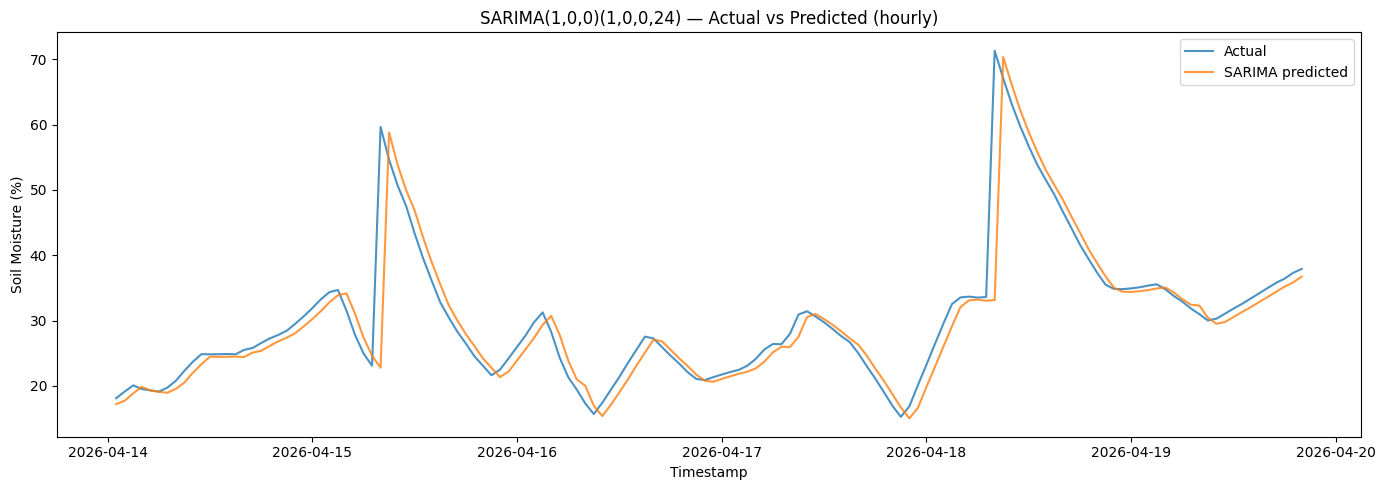

In [43]:
# Cell D — Quick visual: actual vs. predicted (hourly)


import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))
plt.plot(hourly_test.index, y_true_hourly, label="Actual", alpha=0.8)
plt.plot(hourly_test.index, sarima_pred, label="SARIMA predicted", alpha=0.8)
plt.title("SARIMA(1,0,0)(1,0,0,24) — Actual vs Predicted (hourly)")
plt.xlabel("Timestamp")
plt.ylabel("Soil Moisture (%)")
plt.legend()
plt.tight_layout()
plt.show()

In [44]:
# Cell E — Holt-Winters (simple exponential smoothing baseline)

from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Simple trend-only Holt's method (no seasonal component — daily seasonality
# already shown to be weak/non-significant per SARIMA above; forcing a
# seasonal_periods=1440 term here would carry the same cost/justification
# problem as full SARIMA did)
hw_model = ExponentialSmoothing(
    train_df["Soil_Moisture"],
    trend="add",
    seasonal=None,
)
hw_fit = hw_model.fit()
print(hw_fit.summary())

                       ExponentialSmoothing Model Results                       
Dep. Variable:            Soil_Moisture   No. Observations:                33352
Model:             ExponentialSmoothing   SSE                          27268.966
Optimized:                         True   AIC                          -6708.040
Trend:                         Additive   BIC                          -6674.381
Seasonal:                          None   AICC                         -6708.038
Seasonal Periods:                  None   Date:                 Wed, 05 Aug 2026
Box-Cox:                          False   Time:                         07:02:46
Box-Cox Coeff.:                    None                                         
                       coeff                 code              optimized      
------------------------------------------------------------------------------
smoothing_level            0.6952161                alpha                 True
smoothing_trend             0.0000

In [45]:
# Cell F — Holt-Winters one-step-ahead-style evaluation

# ExponentialSmoothing doesn't support get_prediction with dynamic=False the
# same way SARIMAX does, so we refit on an expanding window is expensive at
# this scale — instead, use the standard forecast from end-of-train as the
# comparable "same information as ARIMA's forecast() call" baseline, then
# apply the same one-step correction logic: refit on full data, predict in-sample
# over the test range.
full_hw_model = ExponentialSmoothing(
    df["Soil_Moisture"],
    trend="add",
    seasonal=None,
)
full_hw_fit = full_hw_model.fit()

hw_pred = full_hw_fit.fittedvalues.iloc[split_idx:].values

rmse_hw = np.sqrt(mean_squared_error(y_true, hw_pred))
mae_hw = mean_absolute_error(y_true, hw_pred)
r2_hw = r2_score(y_true, hw_pred)

print(f"Holt-Winters (trend only) — RMSE: {rmse_hw:.4f}  MAE: {mae_hw:.4f}  R2: {r2_hw:.4f}")

results_df = pd.concat([results_df, pd.DataFrame([{
    "fold": "holdout", "model": "Holt-Winters", "rmse": rmse_hw, "mae": mae_hw, "r2": r2_hw
}])], ignore_index=True)

Holt-Winters (trend only) — RMSE: 1.1022  MAE: 0.5265  R2: 0.9890


# Phase 3 — Sequence Deep Learning Models (LSTM/GRU)

In [46]:
# Scale features properly (fit on train only — corrects the stale _scaled columns issue from Phase 0)


from sklearn.preprocessing import MinMaxScaler

feature_cols = ["Soil_Moisture", "Temperature", "Humidity", "Hour_sin", "Hour_cos", "irrigation_status"]
target_col = "soil_moisture_next_1m"

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

train_X_scaled = scaler_X.fit_transform(train_df[feature_cols])
test_X_scaled = scaler_X.transform(test_df[feature_cols])

train_y_scaled = scaler_y.fit_transform(train_df[[target_col]])
test_y_scaled = scaler_y.transform(test_df[[target_col]])

print(f"Train features shape: {train_X_scaled.shape}")
print(f"Test features shape:  {test_X_scaled.shape}")

Train features shape: (33352, 6)
Test features shape:  (8339, 6)


In [47]:
# Build sliding windows (sequence length is the one deliberate hyperparameter to justify)


def create_sequences(X, y, seq_length):
    X_seq, y_seq = [], []
    for i in range(len(X) - seq_length):
        X_seq.append(X[i:i + seq_length])
        y_seq.append(y[i + seq_length])
    return np.array(X_seq), np.array(y_seq)

# 60-minute lookback: chosen because ACF/PACF (Phase 1.3) showed PACF cuts off
# sharply after lag 1-2, but ACF still carries meaningful correlation out to
# ~60 lags — 60 minutes gives the model room to see the recent trajectory
# (including any sharp rises) without an arbitrarily long, harder-to-train window.
SEQ_LENGTH = 60

X_train_seq, y_train_seq = create_sequences(train_X_scaled, train_y_scaled, SEQ_LENGTH)
X_test_seq, y_test_seq = create_sequences(test_X_scaled, test_y_scaled, SEQ_LENGTH)

print(f"X_train_seq: {X_train_seq.shape}  y_train_seq: {y_train_seq.shape}")
print(f"X_test_seq:  {X_test_seq.shape}  y_test_seq:  {y_test_seq.shape}")

X_train_seq: (33292, 60, 6)  y_train_seq: (33292, 1)
X_test_seq:  (8279, 60, 6)  y_test_seq:  (8279, 1)


In [48]:
# Build a modest LSTM (input window → LSTM → dense → output, as planned)


import tensorflow as tf
from tensorflow.keras import layers, models

tf.random.set_seed(42)

n_features = X_train_seq.shape[2]

lstm_model = models.Sequential([
    layers.Input(shape=(SEQ_LENGTH, n_features)),
    layers.LSTM(32),          # single layer, modest width — deliberately not stacked/tuned further
    layers.Dense(16, activation="relu"),
    layers.Dense(1),
])

lstm_model.compile(optimizer="adam", loss="mse", metrics=["mae"])
lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │         4,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,537 (21.63 KB)

 Trainable params: 5,537 (21.63 KB)

 Non-trainable params: 0 (0.00 B)

In [49]:
# Train LSTM

history = lstm_model.fit(
    X_train_seq, y_train_seq,
    validation_split=0.1,
    epochs=20,
    batch_size=128,
    verbose=1,
)

Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - loss: 0.0116 - mae: 0.0481 - val_loss: 7.2094e-04 - val_mae: 0.0116
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - loss: 4.9737e-04 - mae: 0.0110 - val_loss: 4.7818e-04 - val_mae: 0.0095
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - loss: 3.9466e-04 - mae: 0.0101 - val_loss: 4.3418e-04 - val_mae: 0.0096
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - loss: 3.6251e-04 - mae: 0.0098 - val_loss: 4.2517e-04 - val_mae: 0.0097
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - loss: 3.4914e-04 - mae: 0.0096 - val_loss: 4.2190e-04 - val_mae: 0.0097
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - loss: 3.4290e-04 - mae: 0.0094 - val_loss: 4.1829e-04 - val_mae: 0.0096
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - loss: 3.3915e-04 - mae: 0.0093 - val_loss: 4.1327e-04 - val_mae: 0.0094
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - loss: 3.3631e-04 - mae: 0.0092 - val_loss: 4.0931e-04 - val_

In [50]:
# Evaluate LSTM (inverse-transform back to real % units before computing metrics)


lstm_pred_scaled = lstm_model.predict(X_test_seq)
lstm_pred = scaler_y.inverse_transform(lstm_pred_scaled).flatten()
y_true_lstm = scaler_y.inverse_transform(y_test_seq).flatten()

rmse_lstm = np.sqrt(mean_squared_error(y_true_lstm, lstm_pred))
mae_lstm = mean_absolute_error(y_true_lstm, lstm_pred)
r2_lstm = r2_score(y_true_lstm, lstm_pred)

print(f"LSTM — RMSE: {rmse_lstm:.4f}  MAE: {mae_lstm:.4f}  R2: {r2_lstm:.4f}")

results_df = pd.concat([results_df, pd.DataFrame([{
    "fold": "holdout", "model": "LSTM", "rmse": rmse_lstm, "mae": mae_lstm, "r2": r2_lstm
}])], ignore_index=True)

259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
LSTM — RMSE: 1.1228  MAE: 0.5551  R2: 0.9885


In [51]:
# GRU (same architecture shape, swap the recurrent layer — deliberate, controlled comparison)


gru_model = models.Sequential([
    layers.Input(shape=(SEQ_LENGTH, n_features)),
    layers.GRU(32),
    layers.Dense(16, activation="relu"),
    layers.Dense(1),
])
gru_model.compile(optimizer="adam", loss="mse", metrics=["mae"])

gru_history = gru_model.fit(
    X_train_seq, y_train_seq,
    validation_split=0.1,
    epochs=20,
    batch_size=128,
    verbose=1,
)

Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - loss: 0.0046 - mae: 0.0327 - val_loss: 4.2018e-04 - val_mae: 0.0094
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - loss: 3.2835e-04 - mae: 0.0089 - val_loss: 4.4557e-04 - val_mae: 0.0106
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - loss: 3.2307e-04 - mae: 0.0088 - val_loss: 4.2757e-04 - val_mae: 0.0101
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - loss: 3.1931e-04 - mae: 0.0087 - val_loss: 3.9010e-04 - val_mae: 0.0088
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - loss: 3.1622e-04 - mae: 0.0085 - val_loss: 3.7638e-04 - val_mae: 0.0083
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - loss: 3.1662e-04 - mae: 0.0085 - val_loss: 3.7273e-04 - val_mae: 0.0081
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - loss: 3.1809e-04 - mae: 0.0086 - val_loss: 3.7887e-04 - val_mae: 0.0083
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - loss: 3.2060e-04 - mae: 0.0087 - val_loss: 3.9028e-04 - val_

In [52]:
# Evaluate GRU


gru_pred_scaled = gru_model.predict(X_test_seq)
gru_pred = scaler_y.inverse_transform(gru_pred_scaled).flatten()

rmse_gru = np.sqrt(mean_squared_error(y_true_lstm, gru_pred))
mae_gru = mean_absolute_error(y_true_lstm, gru_pred)
r2_gru = r2_score(y_true_lstm, gru_pred)

print(f"GRU — RMSE: {rmse_gru:.4f}  MAE: {mae_gru:.4f}  R2: {r2_gru:.4f}")

results_df = pd.concat([results_df, pd.DataFrame([{
    "fold": "holdout", "model": "GRU", "rmse": rmse_gru, "mae": mae_gru, "r2": r2_gru
}])], ignore_index=True)

259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
GRU — RMSE: 1.0960  MAE: 0.5246  R2: 0.9891


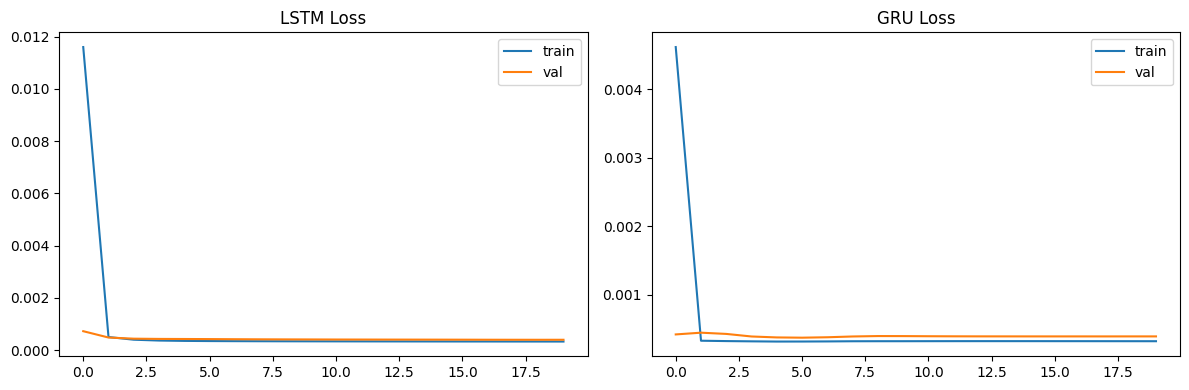

In [53]:
# Training curves (sanity check for over/underfitting)


fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history["loss"], label="train")
axes[0].plot(history.history["val_loss"], label="val")
axes[0].set_title("LSTM Loss")
axes[0].legend()

axes[1].plot(gru_history.history["loss"], label="train")
axes[1].plot(gru_history.history["val_loss"], label="val")
axes[1].set_title("GRU Loss")
axes[1].legend()
plt.tight_layout()
plt.show()

# Phase 4 — Rolling-Origin Cross-Validation + Hypothesis Testing

In [54]:
# Define 5 expanding-window folds (6 chronological blocks total)


N = len(df)
n_blocks = 6  # gives 5 train→test fold transitions
block_size = N // n_blocks
boundaries = [block_size * i for i in range(1, n_blocks + 1)]
boundaries[-1] = N  # last block absorbs remainder

fold_splits = []
for i in range(len(boundaries) - 1):
    train_end = boundaries[i]
    test_end = boundaries[i + 1]
    fold_splits.append((0, train_end, test_end))

for i, (start, train_end, test_end) in enumerate(fold_splits, 1):
    print(f"Fold {i}: train rows 0-{train_end} ({train_end}) | test rows {train_end}-{test_end} ({test_end - train_end})")

Fold 1: train rows 0-6948 (6948) | test rows 6948-13896 (6948)
Fold 2: train rows 0-13896 (13896) | test rows 13896-20844 (6948)
Fold 3: train rows 0-20844 (20844) | test rows 20844-27792 (6948)
Fold 4: train rows 0-27792 (27792) | test rows 27792-34740 (6948)
Fold 5: train rows 0-34740 (34740) | test rows 34740-41691 (6951)


In [55]:
# Helper functions (reused per fold)


from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

exog_cols = ["Hour_sin", "Hour_cos"]
feature_cols = ["Soil_Moisture", "Temperature", "Humidity", "Hour_sin", "Hour_cos", "irrigation_status"]
target_col = "soil_moisture_next_1m"
SEQ_LENGTH = 60

def eval_metrics(y_true, y_pred):
    return (
        np.sqrt(mean_squared_error(y_true, y_pred)),
        mean_absolute_error(y_true, y_pred),
        r2_score(y_true, y_pred),
    )

def create_sequences(X, y, seq_length):
    X_seq, y_seq = [], []
    for i in range(len(X) - seq_length):
        X_seq.append(X[i:i + seq_length])
        y_seq.append(y[i + seq_length])
    return np.array(X_seq), np.array(y_seq)

def fit_arima_exog_fold(train_slice, full_slice, train_len):
    model = SARIMAX(train_slice["Soil_Moisture"], exog=train_slice[exog_cols],
                     order=(1, 0, 0), enforce_stationarity=False, enforce_invertibility=False)
    fit = model.fit(disp=False)
    full_model = SARIMAX(full_slice["Soil_Moisture"], exog=full_slice[exog_cols],
                          order=(1, 0, 0), enforce_stationarity=False, enforce_invertibility=False)
    full_fit = full_model.filter(fit.params)
    pred = full_fit.get_prediction(start=train_len, end=len(full_slice) - 1, dynamic=False)
    return pred.predicted_mean.values

def fit_hw_fold(full_slice, train_len):
    model = ExponentialSmoothing(full_slice["Soil_Moisture"], trend="add", seasonal=None)
    fit = model.fit()
    return fit.fittedvalues.iloc[train_len:].values

def fit_lstm_gru_fold(train_slice, test_slice, cell_type="LSTM", epochs=10):
    scaler_X, scaler_y = MinMaxScaler(), MinMaxScaler()
    train_X = scaler_X.fit_transform(train_slice[feature_cols])
    test_X = scaler_X.transform(test_slice[feature_cols])
    train_y = scaler_y.fit_transform(train_slice[[target_col]])
    test_y = scaler_y.transform(test_slice[[target_col]])

    X_train_seq, y_train_seq = create_sequences(train_X, train_y, SEQ_LENGTH)
    X_test_seq, y_test_seq = create_sequences(test_X, test_y, SEQ_LENGTH)

    layer = tf.keras.layers.LSTM(32) if cell_type == "LSTM" else tf.keras.layers.GRU(32)
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(SEQ_LENGTH, len(feature_cols))),
        layer,
        tf.keras.layers.Dense(16, activation="relu"),
        tf.keras.layers.Dense(1),
    ])
    model.compile(optimizer="adam", loss="mse")
    model.fit(X_train_seq, y_train_seq, epochs=epochs, batch_size=128, verbose=0)

    pred_scaled = model.predict(X_test_seq, verbose=0)
    pred = scaler_y.inverse_transform(pred_scaled).flatten()
    y_true = scaler_y.inverse_transform(y_test_seq).flatten()
    return y_true, pred

print("Helper functions defined.")

Helper functions defined.


In [56]:
# Main rolling-origin CV loop (this will take a few minutes — LSTM/GRU retrain 5x each)



fold_results = []

for fold_num, (start, train_end, test_end) in enumerate(fold_splits, 1):
    print(f"\n=== Fold {fold_num} ===")
    train_slice = df.iloc[start:train_end].reset_index(drop=True)
    test_slice = df.iloc[train_end:test_end].reset_index(drop=True)
    full_slice = df.iloc[start:test_end].reset_index(drop=True)
    train_len = len(train_slice)

    y_true = test_slice[target_col].values
    persist_pred = test_slice["Soil_Moisture"].values
    rmse, mae, r2 = eval_metrics(y_true, persist_pred)
    fold_results.append({"fold": fold_num, "model": "Persistence", "rmse": rmse, "mae": mae, "r2": r2})
    print(f"Persistence   RMSE={rmse:.4f}")

    arima_pred = fit_arima_exog_fold(train_slice, full_slice, train_len)
    rmse, mae, r2 = eval_metrics(y_true, arima_pred)
    fold_results.append({"fold": fold_num, "model": "ARIMA_exog", "rmse": rmse, "mae": mae, "r2": r2})
    print(f"ARIMA_exog    RMSE={rmse:.4f}")

    hw_pred = fit_hw_fold(full_slice, train_len)
    rmse, mae, r2 = eval_metrics(y_true, hw_pred)
    fold_results.append({"fold": fold_num, "model": "Holt-Winters", "rmse": rmse, "mae": mae, "r2": r2})
    print(f"Holt-Winters  RMSE={rmse:.4f}")

    y_true_lstm, lstm_pred = fit_lstm_gru_fold(train_slice, test_slice, "LSTM")
    rmse, mae, r2 = eval_metrics(y_true_lstm, lstm_pred)
    fold_results.append({"fold": fold_num, "model": "LSTM", "rmse": rmse, "mae": mae, "r2": r2})
    print(f"LSTM          RMSE={rmse:.4f}")

    y_true_gru, gru_pred = fit_lstm_gru_fold(train_slice, test_slice, "GRU")
    rmse, mae, r2 = eval_metrics(y_true_gru, gru_pred)
    fold_results.append({"fold": fold_num, "model": "GRU", "rmse": rmse, "mae": mae, "r2": r2})
    print(f"GRU           RMSE={rmse:.4f}")

cv_results_df = pd.DataFrame(fold_results)
print("\n\nFull fold results:")
print(cv_results_df.pivot(index="fold", columns="model", values="rmse").round(4))


=== Fold 1 ===
Persistence   RMSE=0.9784
ARIMA_exog    RMSE=1.1889
Holt-Winters  RMSE=1.1614
LSTM          RMSE=1.4135
GRU           RMSE=1.1755

=== Fold 2 ===
Persistence   RMSE=0.8543
ARIMA_exog    RMSE=0.9835
Holt-Winters  RMSE=0.9354
LSTM          RMSE=1.0883
GRU           RMSE=0.9664

=== Fold 3 ===
Persistence   RMSE=0.9815
ARIMA_exog    RMSE=1.2039
Holt-Winters  RMSE=1.1806
LSTM          RMSE=1.2349
GRU           RMSE=1.1697

=== Fold 4 ===
Persistence   RMSE=0.8623
ARIMA_exog    RMSE=1.0062
Holt-Winters  RMSE=0.9612
LSTM          RMSE=1.0280
GRU           RMSE=1.0019

=== Fold 5 ===
Persistence   RMSE=0.9785
ARIMA_exog    RMSE=1.1964
Holt-Winters  RMSE=1.1731
LSTM          RMSE=1.1561
GRU           RMSE=1.1535


Full fold results:
model  ARIMA_exog     GRU  Holt-Winters    LSTM  Persistence
fold                                                        
1          1.1889  1.1755        1.1614  1.4135       0.9784
2          0.9835  0.9664        0.9354  1.0883       0.8543
3    

In [57]:
# Hypothesis tests (H1: statistical vs. deep learning; also pairwise vs. persistence)



from scipy.stats import ttest_rel, wilcoxon

def compare_models(df_cv, model_a, model_b, metric="rmse"):
    a = df_cv[df_cv.model == model_a].sort_values("fold")[metric].values
    b = df_cv[df_cv.model == model_b].sort_values("fold")[metric].values
    t_stat, t_p = ttest_rel(a, b)
    try:
        w_stat, w_p = wilcoxon(a, b)
    except ValueError:
        w_stat, w_p = np.nan, np.nan
    print(f"{model_a} vs {model_b} ({metric}):")
    print(f"  Mean {model_a}: {a.mean():.4f}  Mean {model_b}: {b.mean():.4f}")
    print(f"  Paired t-test:   t={t_stat:.4f}, p={t_p:.4f}")
    print(f"  Wilcoxon:        W={w_stat:.4f}, p={w_p:.4f}")
    print()

compare_models(cv_results_df, "ARIMA_exog", "LSTM")
compare_models(cv_results_df, "ARIMA_exog", "GRU")
compare_models(cv_results_df, "LSTM", "GRU")
compare_models(cv_results_df, "Persistence", "LSTM")
compare_models(cv_results_df, "Persistence", "ARIMA_exog")

ARIMA_exog vs LSTM (rmse):
  Mean ARIMA_exog: 1.1158  Mean LSTM: 1.1841
  Paired t-test:   t=-1.5077, p=0.2061
  Wilcoxon:        W=3.0000, p=0.3125

ARIMA_exog vs GRU (rmse):
  Mean ARIMA_exog: 1.1158  Mean GRU: 1.0934
  Paired t-test:   t=3.1734, p=0.0337
  Wilcoxon:        W=0.0000, p=0.0625

LSTM vs GRU (rmse):
  Mean LSTM: 1.1841  Mean GRU: 1.0934
  Paired t-test:   t=2.1612, p=0.0968
  Wilcoxon:        W=0.0000, p=0.0625

Persistence vs LSTM (rmse):
  Mean Persistence: 0.9310  Mean LSTM: 1.1841
  Paired t-test:   t=-5.2307, p=0.0064
  Wilcoxon:        W=0.0000, p=0.0625

Persistence vs ARIMA_exog (rmse):
  Mean Persistence: 0.9310  Mean ARIMA_exog: 1.1158
  Paired t-test:   t=-9.2738, p=0.0008
  Wilcoxon:        W=0.0000, p=0.0625

